In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt

from torch import nn
from torchvision import transforms , datasets
from torchinfo import summary
from torch.utils.data import DataLoader , Subset

In [2]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device="mps"
else:
    device="cpu"

In [3]:
device

'mps'

In [4]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

train_dataset = datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)

test_dataset = datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)

test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2) 

In [5]:
def window_partition(x, window_size):
    B, H, W, C = x.shape
    x = x.view(B, H//window_size, window_size, W//window_size, window_size, C)
    x = x.permute(0,1,3,2,4,5)
    windows = x.reshape(-1, window_size, window_size, C)
    return windows

def window_reverse(windows, window_size, H, W):
    B = int(windows.shape[0] / (H*W / window_size / window_size))
    x = windows.view(B, H//window_size, W//window_size, window_size, window_size, -1)
    x = x.permute(0,1,3,2,4,5)
    x = x.reshape(B, H, W, -1)
    return x

In [6]:
class WindowAttention(nn.Module):
    def __init__(self, dim, window_size, num_heads):
        super().__init__()
        self.dim = dim
        self.window_size = window_size
        self.num_heads = num_heads

        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)

        self.relative_position_bias_table = nn.Parameter(
            torch.zeros((2*window_size-1)*(2*window_size-1), num_heads)
        )

        coords = torch.stack(torch.meshgrid(
            torch.arange(window_size),
            torch.arange(window_size),
            indexing="ij"
        ))

        coords_flat = coords.flatten(1)
        relative_coords = coords_flat[:,:,None] - coords_flat[:,None,:]
        relative_coords = relative_coords.permute(1,2,0)

        relative_coords[:,:,0] += window_size-1
        relative_coords[:,:,1] += window_size-1
        relative_coords[:,:,0] *= 2*window_size-1

        self.register_buffer(
            "relative_position_index",
            relative_coords.sum(-1)
        )

    def forward(self, x, mask=None):
        B_, N, C = x.shape

        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, C//self.num_heads)
        qkv = qkv.permute(2,0,3,1,4)
        q,k,v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2,-1)) * self.scale

        bias = self.relative_position_bias_table[
            self.relative_position_index.view(-1)
        ].view(N, N, -1).permute(2,0,1)

        attn = attn + bias.unsqueeze(0)

        if mask is not None:
            nW = mask.shape[0]
            attn = attn.view(B_//nW, nW, self.num_heads, N, N)
            attn = attn + mask.unsqueeze(1).unsqueeze(0)
            attn = attn.view(-1, self.num_heads, N, N)

        attn = attn.softmax(dim=-1)

        x = (attn @ v).transpose(1,2).reshape(B_, N, C)
        x = self.proj(x)
        return x

In [7]:
class SwinTransformerBlock(nn.Module):
    def __init__(self, dim, input_resolution, num_heads, window_size=4, shift_size=0):
        super().__init__()

        self.dim = dim
        self.input_resolution = input_resolution
        self.window_size = window_size
        self.shift_size = shift_size

        self.norm1 = nn.LayerNorm(dim)
        self.attn = WindowAttention(dim, window_size, num_heads)

        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim*4),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(dim*4, dim)
        )

        if shift_size > 0:
            self.attn_mask = create_mask(
                input_resolution[0],
                input_resolution[1],
                window_size,
                shift_size
            )
        else:
            self.attn_mask = None

    def forward(self, x):
        H, W = self.input_resolution
        B, L, C = x.shape

        shortcut = x
        x = self.norm1(x)
        x = x.view(B, H, W, C)

        if self.shift_size > 0:
            x = torch.roll(x, (-self.shift_size,-self.shift_size),(1,2))

        x_windows = window_partition(x, self.window_size)
        x_windows = x_windows.view(-1, self.window_size*self.window_size, C)

        mask = self.attn_mask.to(x.device) if self.attn_mask is not None else None

        attn_windows = self.attn(x_windows, mask=mask)

        attn_windows = attn_windows.view(-1, self.window_size, self.window_size, C)
        x = window_reverse(attn_windows, self.window_size, H, W)

        if self.shift_size > 0:
            x = torch.roll(x, (self.shift_size,self.shift_size),(1,2))

        x = x.view(B, H*W, C)

        x = shortcut + x
        x = x + self.mlp(self.norm2(x))

        return x

In [8]:
class PatchMerging(nn.Module):
    def __init__(self, input_resolution, dim):
        super().__init__()

        self.reduction = nn.Linear(4*dim, 2*dim)
        self.norm = nn.LayerNorm(4*dim)
        self.input_resolution = input_resolution

    def forward(self, x):
        H, W = self.input_resolution
        B, L, C = x.shape

        x = x.view(B, H, W, C)

        x0 = x[:,0::2,0::2,:]
        x1 = x[:,1::2,0::2,:]
        x2 = x[:,0::2,1::2,:]
        x3 = x[:,1::2,1::2,:]

        x = torch.cat([x0,x1,x2,x3], -1)
        x = x.view(B, -1, 4*C)

        x = self.norm(x)
        x = self.reduction(x)

        return x

In [9]:
def create_mask(H, W, window_size, shift_size):
    img_mask = torch.zeros((1, H, W, 1))

    cnt = 0
    for h in (
        slice(0, -window_size),
        slice(-window_size, -shift_size),
        slice(-shift_size, None)
    ):
        for w in (
            slice(0, -window_size),
            slice(-window_size, -shift_size),
            slice(-shift_size, None)
        ):
            img_mask[:, h, w, :] = cnt
            cnt += 1

    mask_windows = window_partition(img_mask, window_size)
    mask_windows = mask_windows.view(-1, window_size * window_size)

    attn_mask = mask_windows.unsqueeze(1) - mask_windows.unsqueeze(2)

    attn_mask = attn_mask.masked_fill(attn_mask != 0, float('-inf'))
    attn_mask = attn_mask.masked_fill(attn_mask == 0, 0.0)

    return attn_mask

In [10]:
class SwinTransformer(nn.Module):
    def __init__(self):
        super().__init__()

        self.patch_embed = nn.Conv2d(3, 48, kernel_size=2, stride=2)

        self.stage1 = nn.Sequential(
            SwinTransformerBlock(48,(16,16),3,4,0),
            SwinTransformerBlock(48,(16,16),3,4,2)
        )

        self.merge1 = PatchMerging((16,16),48)

        self.stage2 = nn.Sequential(
            SwinTransformerBlock(96,(8,8),6,4,0),
            SwinTransformerBlock(96,(8,8),6,4,2)
        )

        self.merge2 = PatchMerging((8,8),96)

        self.stage3 = nn.Sequential(
            SwinTransformerBlock(192,(4,4),12,4,0),
            SwinTransformerBlock(192,(4,4),12,4,2)
        )

        self.norm = nn.LayerNorm(192)
        self.head = nn.Linear(192,10)

    def forward(self, x):
        x = self.patch_embed(x)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)

        x = self.stage1(x)
        x = self.merge1(x)

        x = self.stage2(x)
        x = self.merge2(x)

        x = self.stage3(x)

        x = self.norm(x)
        x = x.mean(dim=1)
        x = self.head(x)

        return x

In [11]:
train_acc_list = []
test_acc_list = []
train_loss_list = []


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    avg_loss = total_loss / total
    acc = 100. * correct / total

    return avg_loss, acc

In [12]:
def evaluate(model, loader, device):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    acc = 100. * correct / total
    return acc

In [13]:
model = SwinTransformer().to(device)

criterion = nn.CrossEntropyLoss()


optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.05)


scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)


epochs = 20

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    test_acc = evaluate(model, test_loader, device)

    scheduler.step()

    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)
    train_loss_list.append(train_loss)

    print(f"Epoch [{epoch+1:02d}/{epochs}] "
          f"| Loss: {train_loss:.4f} "
          f"| Train Acc: %{train_acc:.2f} "
          f"| Test Acc: %{test_acc:.2f}")

Epoch [01/20] | Loss: 1.7248 | Train Acc: %35.75 | Test Acc: %45.66
Epoch [02/20] | Loss: 1.3757 | Train Acc: %50.10 | Test Acc: %53.31
Epoch [03/20] | Loss: 1.2282 | Train Acc: %55.52 | Test Acc: %57.46
Epoch [04/20] | Loss: 1.1227 | Train Acc: %59.53 | Test Acc: %61.31
Epoch [05/20] | Loss: 1.0411 | Train Acc: %62.70 | Test Acc: %61.96
Epoch [06/20] | Loss: 0.9815 | Train Acc: %64.91 | Test Acc: %66.34
Epoch [07/20] | Loss: 0.9143 | Train Acc: %67.48 | Test Acc: %67.81
Epoch [08/20] | Loss: 0.8582 | Train Acc: %69.47 | Test Acc: %68.77
Epoch [09/20] | Loss: 0.8102 | Train Acc: %71.13 | Test Acc: %70.63
Epoch [10/20] | Loss: 0.7683 | Train Acc: %72.78 | Test Acc: %70.91
Epoch [11/20] | Loss: 0.7309 | Train Acc: %74.07 | Test Acc: %72.22
Epoch [12/20] | Loss: 0.6986 | Train Acc: %75.28 | Test Acc: %73.69
Epoch [13/20] | Loss: 0.6660 | Train Acc: %76.31 | Test Acc: %74.21
Epoch [14/20] | Loss: 0.6374 | Train Acc: %77.40 | Test Acc: %75.08
Epoch [15/20] | Loss: 0.6155 | Train Acc: %78.25

In [18]:
y_true = []
y_pred = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = outputs.max(1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

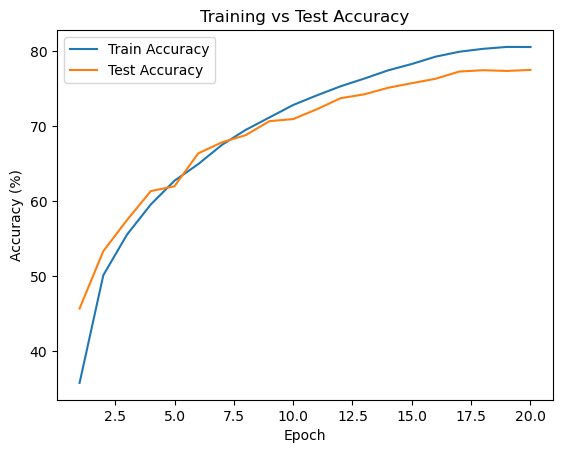

In [19]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(train_acc_list)+1))

plt.figure()
plt.plot(epochs, train_acc_list, label="Train Accuracy")
plt.plot(epochs, test_acc_list, label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Test Accuracy")

plt.legend()
plt.show()

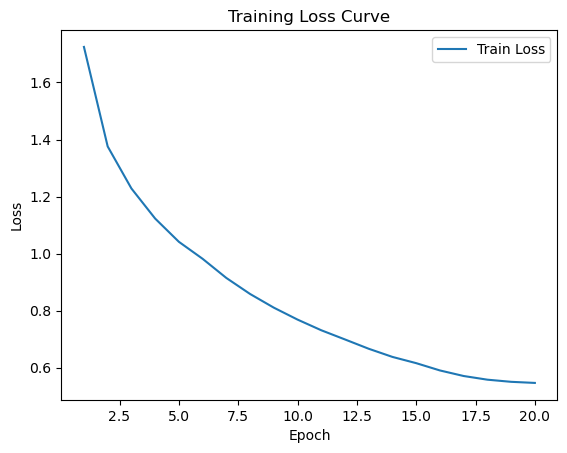

In [20]:
plt.figure()
plt.plot(epochs, train_loss_list, label="Train Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.legend()
plt.show()

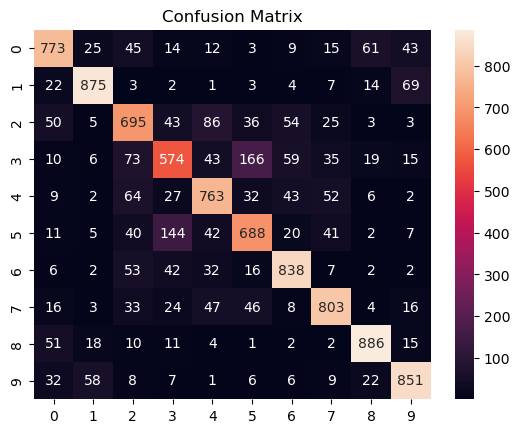

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()